# Taxi Fare
predict the taxi fare using linear regression over three features

full batch gradient descent

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [27]:
chicago_taxi_dataset = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")
chicago_taxi_dataset = chicago_taxi_dataset.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]

chicago_taxi_dataset.head()

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0


In [28]:
chicago_taxi_dataset.describe(include='all')

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [29]:
chicago_taxi_dataset.corr(numeric_only = True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [30]:
X = chicago_taxi_dataset[["TRIP_MILES", "TRIP_SECONDS", "TIP_RATE"]]
y = chicago_taxi_dataset["FARE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Unsqueeze converts the 1D tensor of shape (n,) to a 2D tensor of shape (n, 1)
# Essentially turning the flat list into a column
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32, device=device).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32, device=device).unsqueeze(1)

In [34]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)  

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.linear(x)
        return out

In [ ]:
def train_model(
    model: nn.Module, 
    criterion: nn.Module, 
    optimizer: torch.optim.Optimizer, 
    X_train: torch.Tensor, 
    y_train: torch.Tensor, 
    epochs: int,
) -> list[float]:
    loss_history = []
    for epoch in range(epochs):
        # Set model to training mode
        model.train()

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad() 

        # Forward to get output and calculate loss
        loss = criterion(model(X_train), y_train)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        # Save the loss for this epoch
        loss_history.append(loss.item())
        print('epoch {}, loss {}'.format(epoch, loss.item()))
        
    return loss_history

In [37]:
epochs = 100
criterion = nn.MSELoss()
learning_rate = 0.1
model = LinearRegressionModel(X_train_t.shape[1], 1).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

loss_history = train_model(model, criterion, optimizer, X_train_t, y_train_t, epochs)

epoch 0, loss 877.6732177734375
epoch 1, loss 505.317138671875
epoch 2, loss 305.09417724609375
epoch 3, loss 192.27276611328125
epoch 4, loss 126.14555358886719
epoch 5, loss 86.15628051757812
epoch 6, loss 61.38294219970703
epoch 7, loss 45.74290084838867
epoch 8, loss 35.71146774291992
epoch 9, loss 29.18181610107422
epoch 10, loss 24.865447998046875
epoch 11, loss 21.961503982543945
epoch 12, loss 19.96651268005371
epoch 13, loss 18.561424255371094
epoch 14, loss 17.54286003112793
epoch 15, loss 16.78055191040039
epoch 16, loss 16.190673828125
epoch 17, loss 15.719015121459961
epoch 18, loss 15.33031177520752
epoch 19, loss 15.001442909240723
epoch 20, loss 14.717096328735352
epoch 21, loss 14.466980934143066
epoch 22, loss 14.244075775146484
epoch 23, loss 14.04347038269043
epoch 24, loss 13.861641883850098
epoch 25, loss 13.695988655090332
epoch 26, loss 13.544515609741211
epoch 27, loss 13.405656814575195
epoch 28, loss 13.278129577636719
epoch 29, loss 13.160861015319824
epoch 

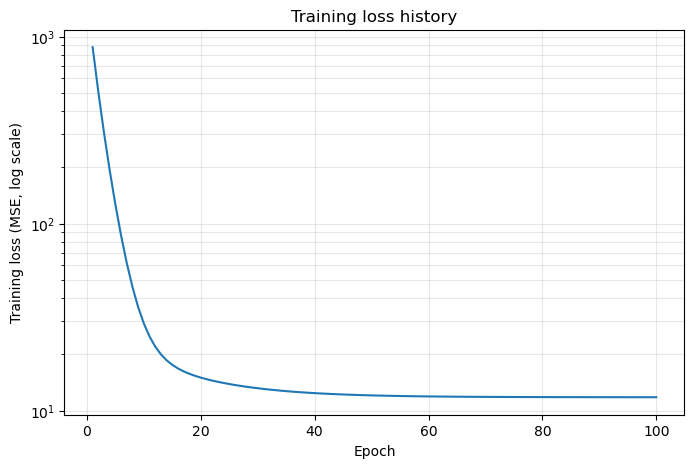

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE, log scale)")
plt.title("Training loss history")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [42]:
def evaluate_model(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
) -> dict[str, float]:
    model.eval()
    with torch.no_grad():
        preds = model(X)

    y_true = y.cpu().numpy()
    y_pred = preds.cpu().numpy()

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

metrics = pd.DataFrame({
    "train": evaluate_model(model, X_train_t, y_train_t),
    "test": evaluate_model(model, X_test_t, y_test_t),
})
metrics.round(3)

,train,test
MAE,1.167,1.229
MSE,11.782,12.927
RMSE,3.433,3.595
R2,0.959,0.956


In [43]:
# Compare a few test predictions against the actual fares
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).cpu().numpy().squeeze(1)

comparison = pd.DataFrame({
    "actual_fare": y_test_t.cpu().numpy().squeeze(1),
    "predicted_fare": test_preds,
})
comparison["error"] = comparison["predicted_fare"] - comparison["actual_fare"]
comparison.head(10).round(2)

,actual_fare,predicted_fare,error
0,14.840000,15.830000,0.99
1,4.750000,4.950000,0.20
2,33.500000,33.529999,0.03
3,23.000000,23.730000,0.73
4,9.680000,9.590000,-0.09
5,46.250000,44.779999,-1.47
6,9.750000,10.770000,1.02
7,11.750000,11.520000,-0.23
8,58.709999,45.150002,-13.56
9,8.000000,8.030000,0.03
